# Churn Prediction with XGBoost

This notebook builds the predictive model used by the Flask application. It uses IBM's public Telco Customer Churn dataset and keeps the workflow readable.

In [1]:
import os
import urllib.request
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
DATA_PATH = "../data/Telco-Customer-Churn.csv"
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)


## 1. Download the public dataset

In [2]:
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Basic inspection and cleaning

In [3]:
df.info()
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head())
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)
print("Churn rate:", round((df["Churn"] == "Yes").mean(), 3))


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Quick exploratory analysis

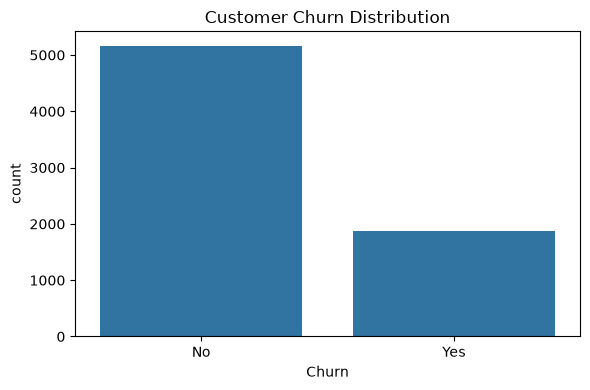

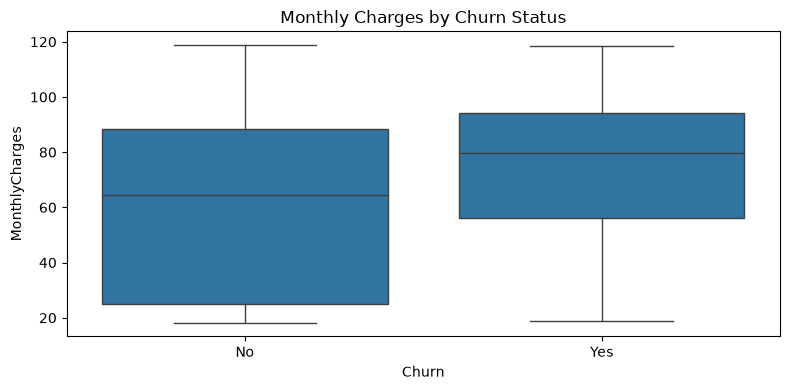

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Customer Churn Distribution")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax)
ax.set_title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()


## 4. Prepare features

In [5]:
target = "Churn"
X = df.drop(columns=[target, "customerID"])
y = (df[target] == "Yes").astype(int)
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("numeric", "passthrough", numeric_features),
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Categorical:", categorical_features)
print("Numeric:", numeric_features)


C:\Users\user\AppData\Local\Temp\ipykernel_6092\1215999811.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']


## 5. Train XGBoost

In [6]:
model = XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=4)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 6. Evaluate the model

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC: 0.8333


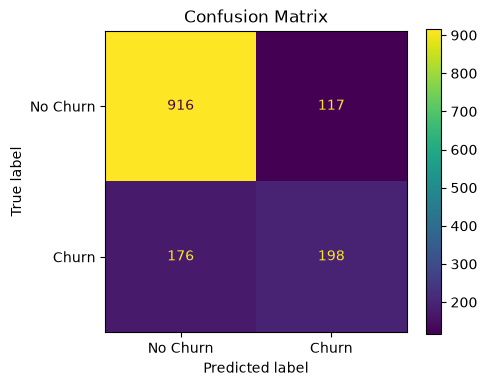

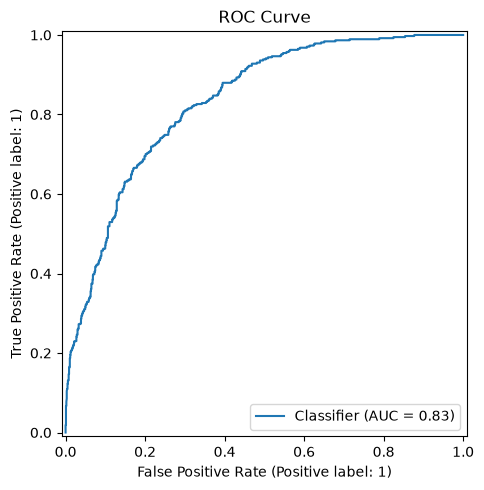

In [7]:
pred = pipeline.predict(X_test)
prob = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, prob), 4))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["No Churn", "Churn"], ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, prob, ax=ax)
ax.set_title("ROC Curve")
plt.tight_layout()
plt.show()


## 7. Save deployment artifacts

In [8]:
joblib.dump(pipeline, "../models/churn_model.joblib")
feature_columns = pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()
joblib.dump(feature_columns, "../models/feature_columns.joblib")
joblib.dump({"categorical_features": categorical_features, "numeric_features": numeric_features, "random_state": RANDOM_STATE}, "../models/model_info.joblib")
print("Model artifacts saved.")


Model artifacts saved.


## 8. Example prediction

In [9]:
example = X_test.iloc[[0]].copy()
example_probability = pipeline.predict_proba(example)[0, 1]
print("Predicted churn probability:", round(float(example_probability), 4))
print("Predicted class:", "Churn" if example_probability >= 0.5 else "No Churn")


Predicted churn probability: 0.0188
Predicted class: No Churn
